# RB2B SaaS Growth & Retention Analysis
### Using Baremetrics Open Startups Public Data

## What This Project Is
RB2B grew from $0 to $780,000 MRR in just 30 months. This analysis uses their 
publicly shared Baremetrics dashboard data to go beyond the headline numbers and 
identify the retention patterns and revenue risks hiding underneath the growth story.

## The Core Finding
RB2B has acquired 7,333 customers since launch. Only 3,729 are active today.
Meanwhile, failed charges total 6,697, nearly matching total customers ever acquired.
The dashboard shows growth. This analysis shows what it costs to sustain it.

## Key Insights
- **60,603% MRR growth** from January 2024 to June 2026
- **Early churn was brutal**: avg 14.2% monthly in the first 6 months
- **Churn stabilized** at ~9.8% after product-market fit was established
- **ARPU declined** from $450 to $209 as RB2B moved downmarket to acquire volume
- **Failed charges (6,697) exceed active customers (3,729)** by 2,968, 
  representing a significant dunning and revenue recovery opportunity

## Data Source
All data manually recorded from RB2B's public Baremetrics dashboard at 
rb2b.baremetrics.com. Monthly values from December 2023 to June 2026.

## Tools Used
Python, Pandas, Matplotlib

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    'month': [
        'Dec-23','Jan-24','Feb-24','Mar-24','Apr-24','May-24',
        'Jun-24','Jul-24','Aug-24','Sep-24','Oct-24','Nov-24',
        'Dec-24','Jan-25','Feb-25','Mar-25','Apr-25','May-25',
        'Jun-25','Jul-25','Aug-25','Sep-25','Oct-25','Nov-25',
        'Dec-25','Jan-26','Feb-26','Mar-26','Apr-26','May-26','Jun-26'
    ],
    'mrr': [
        0,1285,3750,5340,19420,44376,
        96176,165433,218291,260612,316561,340724,
        344621,375687,400479,413915,421306,434358,
        454825,475574,496937,522776,546562,554781,
        552338,598809,635130,665960,710201,759443,780036
    ],
    'active_customers': [
        0,3,10,12,44,99,
        335,604,803,983,1252,1371,
        1376,1501,1629,1706,1755,1851,
        1977,2076,2144,2278,2399,2404,
        2394,2770,2985,3138,3381,3598,3729
    ],
    'user_churn_pct': [
        0,0,0,40,16.7,29.8,
        13.1,9.7,14.1,11.6,11.9,12.1,
        10.5,9.5,10.1,10.1,9.7,8.9,
        7.0,8.1,8.9,8.6,8.1,11.0,
        9.5,8.7,9.8,10.0,9.9,8.1,9.2
    ]
}

df = pd.DataFrame(data)
df['month'] = pd.to_datetime(df['month'], format='%b-%y')
print(df)

        month     mrr  active_customers  user_churn_pct
0  2023-12-01       0                 0             0.0
1  2024-01-01    1285                 3             0.0
2  2024-02-01    3750                10             0.0
3  2024-03-01    5340                12            40.0
4  2024-04-01   19420                44            16.7
5  2024-05-01   44376                99            29.8
6  2024-06-01   96176               335            13.1
7  2024-07-01  165433               604             9.7
8  2024-08-01  218291               803            14.1
9  2024-09-01  260612               983            11.6
10 2024-10-01  316561              1252            11.9
11 2024-11-01  340724              1371            12.1
12 2024-12-01  344621              1376            10.5
13 2025-01-01  375687              1501             9.5
14 2025-02-01  400479              1629            10.1
15 2025-03-01  413915              1706            10.1
16 2025-04-01  421306              1755         

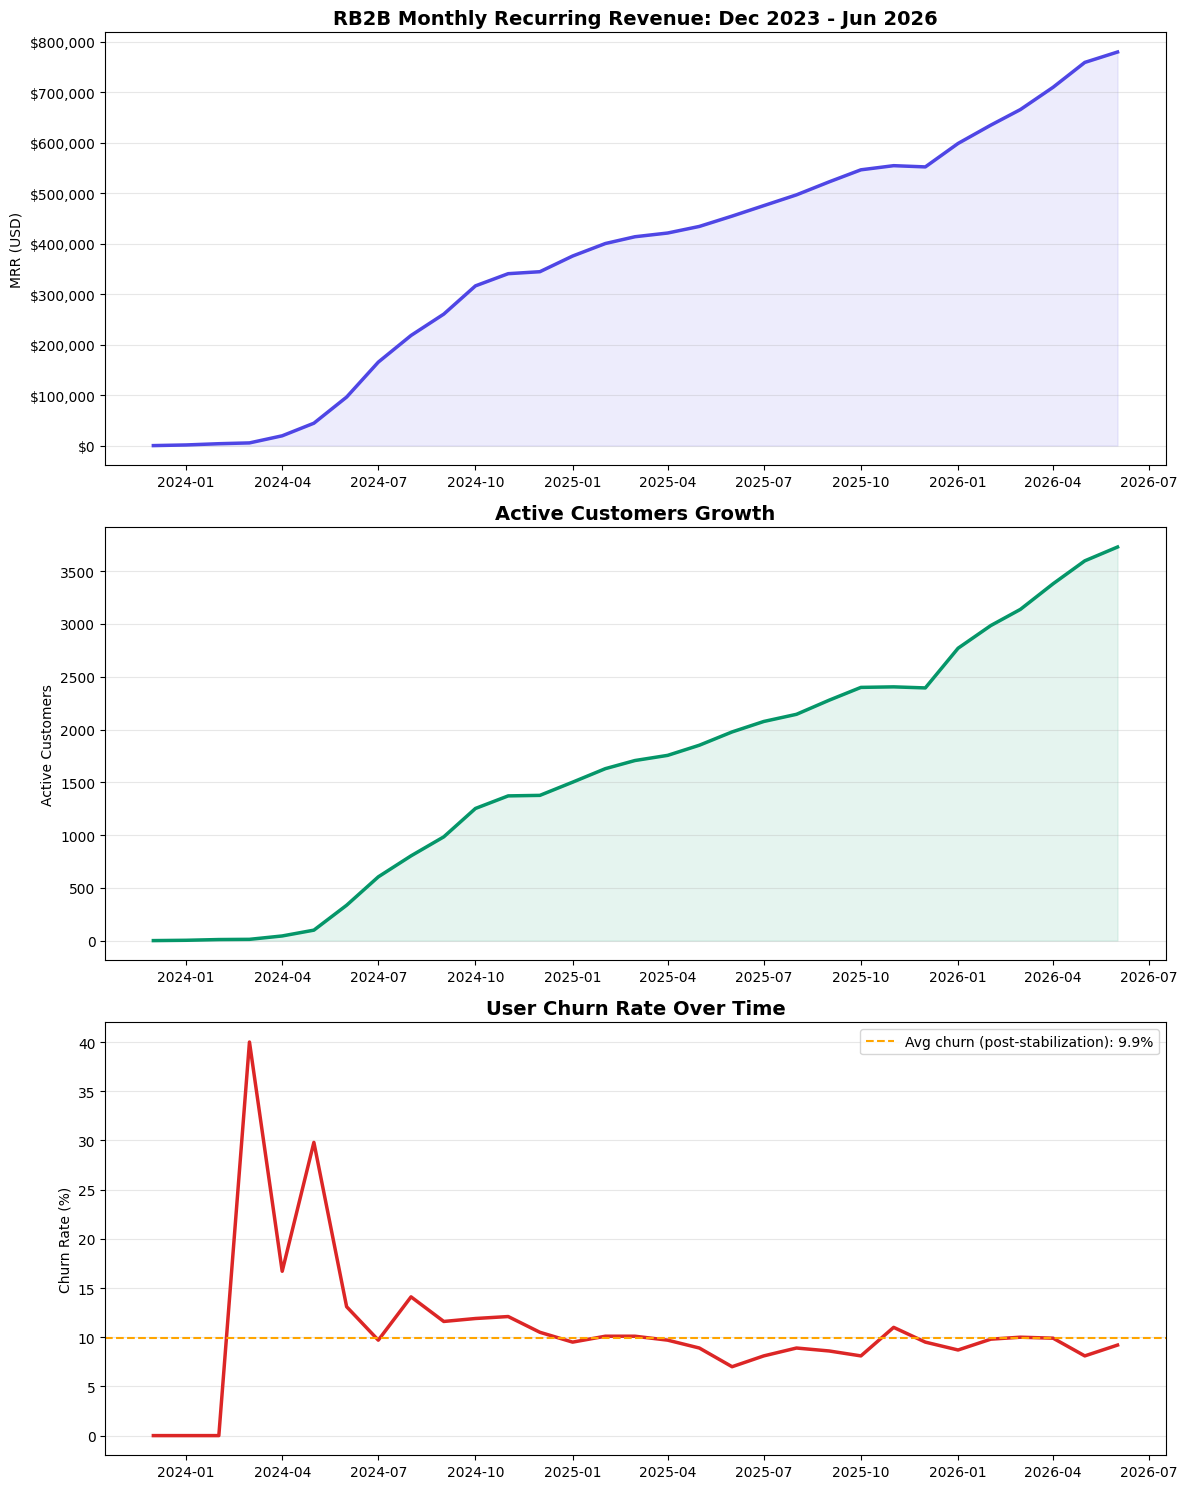

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# MRR Growth
axes[0].plot(df['month'], df['mrr'], color='#4F46E5', linewidth=2.5)
axes[0].fill_between(df['month'], df['mrr'], alpha=0.1, color='#4F46E5')
axes[0].set_title('RB2B Monthly Recurring Revenue: Dec 2023 - Jun 2026', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MRR (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].grid(axis='y', alpha=0.3)

# Active Customers
axes[1].plot(df['month'], df['active_customers'], color='#059669', linewidth=2.5)
axes[1].fill_between(df['month'], df['active_customers'], alpha=0.1, color='#059669')
axes[1].set_title('Active Customers Growth', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Active Customers')
axes[1].grid(axis='y', alpha=0.3)

# Churn Rate
axes[2].plot(df['month'], df['user_churn_pct'], color='#DC2626', linewidth=2.5)
axes[2].axhline(y=df['user_churn_pct'][6:].mean(), color='orange', 
                linestyle='--', label=f'Avg churn (post-stabilization): {df["user_churn_pct"][6:].mean():.1f}%')
axes[2].set_title('User Churn Rate Over Time', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rb2b_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Key Insights Calculation
early_churn = df[df['month'] < '2024-07-01']['user_churn_pct']
stable_churn = df[df['month'] >= '2024-07-01']['user_churn_pct']

mrr_growth = ((df['mrr'].iloc[-1] - df['mrr'].iloc[1]) / df['mrr'].iloc[1]) * 100

customer_growth = df['active_customers'].iloc[-1] - df['active_customers'].iloc[1]

# Revenue per customer trend
df['arpu'] = df['mrr'] / df['active_customers'].replace(0, np.nan)

# Failed charges context
total_new_customers = 7333
total_churned = 4378
total_failed_charges = 6697
retention_rate = (total_new_customers - total_churned) / total_new_customers * 100

print("=" * 50)
print("RB2B GROWTH ANALYSIS - KEY FINDINGS")
print("=" * 50)
print(f"\n1. MRR Growth (Jan 2024 to Jun 2026): {mrr_growth:,.0f}%")
print(f"\n2. Early churn avg (Dec23-Jun24): {early_churn.mean():.1f}%")
print(f"   Stable churn avg (Jul24-Jun26): {stable_churn.mean():.1f}%")
print(f"   Churn improvement: {early_churn.mean() - stable_churn.mean():.1f} percentage points")
print(f"\n3. Customers acquired: {total_new_customers:,}")
print(f"   Customers churned: {total_churned:,}")
print(f"   Net retention rate: {retention_rate:.1f}%")
print(f"\n4. Failed charges: {total_failed_charges:,}")
print(f"   Failed charges exceed active customers by: {total_failed_charges - df['active_customers'].iloc[-1]:,}")
print(f"\n5. Current ARPU: ${df['arpu'].iloc[-1]:,.2f}")

RB2B GROWTH ANALYSIS - KEY FINDINGS

1. MRR Growth (Jan 2024 to Jun 2026): 60,603%

2. Early churn avg (Dec23-Jun24): 14.2%
   Stable churn avg (Jul24-Jun26): 9.8%
   Churn improvement: 4.4 percentage points

3. Customers acquired: 7,333
   Customers churned: 4,378
   Net retention rate: 40.3%

4. Failed charges: 6,697
   Failed charges exceed active customers by: 2,968

5. Current ARPU: $209.18


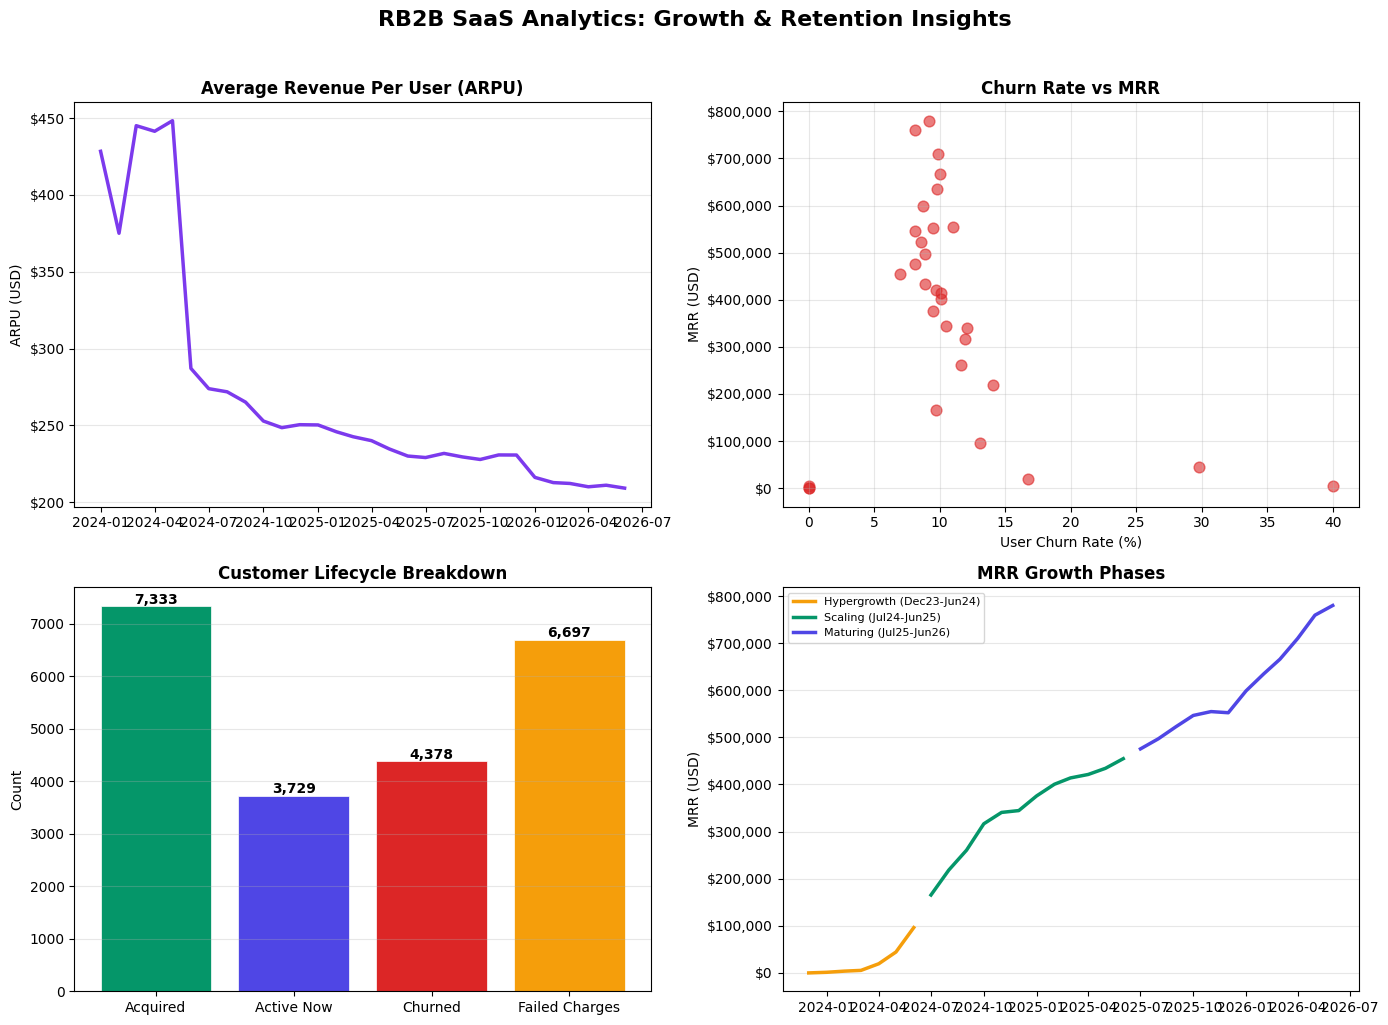

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RB2B SaaS Analytics: Growth & Retention Insights', 
             fontsize=16, fontweight='bold', y=1.02)

# ARPU over time
df_clean = df[df['active_customers'] > 0].copy()
axes[0,0].plot(df_clean['month'], df_clean['arpu'], color='#7C3AED', linewidth=2.5)
axes[0,0].set_title('Average Revenue Per User (ARPU)', fontweight='bold')
axes[0,0].set_ylabel('ARPU (USD)')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0,0].grid(axis='y', alpha=0.3)

# Churn vs MRR growth correlation
axes[0,1].scatter(df['user_churn_pct'], df['mrr'], 
                  color='#DC2626', alpha=0.6, s=60)
axes[0,1].set_title('Churn Rate vs MRR', fontweight='bold')
axes[0,1].set_xlabel('User Churn Rate (%)')
axes[0,1].set_ylabel('MRR (USD)')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0,1].grid(alpha=0.3)

# Customer funnel
categories = ['Acquired', 'Active Now', 'Churned', 'Failed Charges']
values = [7333, 3729, 4378, 6697]
colors = ['#059669', '#4F46E5', '#DC2626', '#F59E0B']
bars = axes[1,0].bar(categories, values, color=colors, edgecolor='white', linewidth=0.5)
axes[1,0].set_title('Customer Lifecycle Breakdown', fontweight='bold')
axes[1,0].set_ylabel('Count')
for bar, val in zip(bars, values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                   f'{val:,}', ha='center', fontweight='bold', fontsize=10)
axes[1,0].grid(axis='y', alpha=0.3)

# MRR growth phases
phase1 = df[df['month'] <= '2024-06-01']
phase2 = df[(df['month'] > '2024-06-01') & (df['month'] <= '2025-06-01')]
phase3 = df[df['month'] > '2025-06-01']
axes[1,1].plot(phase1['month'], phase1['mrr'], color='#F59E0B', linewidth=2.5, label='Hypergrowth (Dec23-Jun24)')
axes[1,1].plot(phase2['month'], phase2['mrr'], color='#059669', linewidth=2.5, label='Scaling (Jul24-Jun25)')
axes[1,1].plot(phase3['month'], phase3['mrr'], color='#4F46E5', linewidth=2.5, label='Maturing (Jul25-Jun26)')
axes[1,1].set_title('MRR Growth Phases', fontweight='bold')
axes[1,1].set_ylabel('MRR (USD)')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[1,1].legend(fontsize=8)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rb2b_insights.png', dpi=150, bbox_inches='tight')
plt.show()